# **TP : n-body problem**

## Imports

In [256]:
import numpy as np
import matplotlib.pyplot as plt

## Échauffement : le broadcasting

### 1.

In [257]:
a = np.array([1,2,3])
print(f"{a}\nest de taille {a.shape}.\n")
print(f"{a[:,None]}\nest de taille {a[:,None].shape}.\n")
print(f"{a[None,:]}\nest de taille {a[None,:].shape}.")

[1 2 3]
est de taille (3,).

[[1]
 [2]
 [3]]
est de taille (3, 1).

[[1 2 3]]
est de taille (1, 3).


`a[:,None]` est de taille (3,1) (3 lignes, 1 colonne), et `a[None,:]`est de taille (1,3) (1 ligne, 3 colonnes).

### 2.

In [258]:
print(f"{a[:,None]-a[None,:]}\nest de taille {(a[:,None]-a[None,:]).shape}.")

[[ 0 -1 -2]
 [ 1  0 -1]
 [ 2  1  0]]
est de taille (3, 3).


Pour calculer `a[:,None] - a[None,:]`, les deux tableaus sont étendus en taille (3,3) en dupliquant l'unique colonne / ligne. Puis on soustrait terme à terme. On obtient un tableau de taille (3,3). L'élement `[i,j]` correspond donc à `a[:,None][i:0] - a[None,:][0:j]`, soit `a[i] - a[j]`.

### 3.

In [259]:
b = np.array([[1,2,3],[4,5,6]])
print(f"{b}\nest de taille {b.shape}.\n")
print(f"{b[:,None,:]}\nest de taille {b[:,None,:].shape}.\n")
print(f"{b[:,:,None]}\nest de taille {b[:,:,None].shape}.\n")
print(f"{b[:,None,:]-b[:,:,None]}\nest de taille {(b[:,None,:]-b[:,:,None]).shape}.")

[[1 2 3]
 [4 5 6]]
est de taille (2, 3).

[[[1 2 3]]

 [[4 5 6]]]
est de taille (2, 1, 3).

[[[1]
  [2]
  [3]]

 [[4]
  [5]
  [6]]]
est de taille (2, 3, 1).

[[[ 0  1  2]
  [-1  0  1]
  [-2 -1  0]]

 [[ 0  1  2]
  [-1  0  1]
  [-2 -1  0]]]
est de taille (2, 3, 3).


`b[:,None,:]`sera un tableau de taille (2,1,3) et `b[:,:,None]`sera un tableau de taille (2,3,1). On veut faire l'opération `b[:,None,:] - b[:,:,None]`. On compare les tailles par la droite : d'abord 3 vs 1, donc le 2eme tableau duplique ses données pour devenir de taille (2,3,3) dans le calcul. Ensuite 1 vs 3, donc le 1er tableau duplique ses données pour devenir de taille (2,3,3) dans le calcul. Enfin 2 vs 2 c'est bon. On peut maintenant soustraire terme à terme. L'élément [i,j,k] correspond donc à `b[:,None,:][i,0,k] - b[:,:,None][i,j,0]`, soit `b[i,k] - b[i,j]`.

## Initialisation aléatoire

In [260]:
def masse_aleatoire():
    return 3.*(1-np.random.random())

# np.random.random() renvoie un flottant entre 0 inclus et 1 exclu, donc
# 1 - np.random.random() renvoie un flottant entre 0 exclu et 1 inclus,
# et donc la fonction renvoie un flottant entre 0 exclu et 3 inclus

def x_y_aleatoire():
    return np.random.uniform(-10.,10.)

# Cette fonction renvoie un flottant entre -10 inclus et 10 exclu

def vitesse_aleatoire():
    return np.random.random()

#Cette fonction renvoie un flottant entre 0 inclus et 1 exclu

def init_problem(N):
    masses = np.array([masse_aleatoire() for i in range(N)])
    positions = np.array([[x_y_aleatoire() for i in range(N)],[x_y_aleatoire() for i in range(N)]])
    speeds = np.array([[vitesse_aleatoire() for i in range(N)],[vitesse_aleatoire() for i in range(N)]])
    return masses, positions, speeds

# (Pour les positions et les vitesses on a deux lignes qui correspondent aux axes x et y

# Vérification :

masses, positions, speeds = init_problem(10)

try:
    assert masses.shape == (10,) and positions.shape == speeds.shape == (2, 10)
    print("OK")
except:
    print("KO")

OK


## Initialisation reproductible

In [261]:
def init3():
    # first element is sun-like: heavy, at the center, and no speed
    masses = np.array([3, 1, 1], dtype=float)
    positions = np.array([
        [0, 5, -5], 
        [0, 1, -1]], dtype=float)
    speeds = np.array([
        [0, -1, 1], 
        [0, 0, 0]], dtype=float)
    return masses, positions, speeds

## Les forces

In [262]:
def forces(masses, positions, G=1.0):
    diff = positions[:,None,:] - positions[:,:,None]
    # diff[0,i,j] correspond à x_j - x_i, et diff[1,i,j] correspond à y_j - y_i
    dist = np.linalg.norm(diff,axis=0)
    # Cela permet de calculer la norme 2, c'est-à-dire les distances entre chaque particule
    np.fill_diagonal(dist,np.inf)
    # On dit qu'une particule est infiniment éloignée d'elle-même pour qu'elle n'agisse pas sur elle-même
    coeff = G * masses[:,None] * masses[None,:]
    # Cela correspond aux coefficients Gm_im_j
    forces = coeff[None,:,:] * diff / (dist[None,:,:]**3)
    # forces[0,i,j] correspond à la force selon x exercée par la particule j sur la particule i, et forces[1,i,j], selon y
    force_totale = np.sum(forces,axis=2)
    # On somme pour obtenir la force totale s'appliquant à chaque particule
    return force_totale

# Vérification :

masses,positions,speeds = init3()
f = forces(masses, positions)
np.all(np.isclose(f,np.array([[ 0.,-0.12257258,0.12257258],[0.,-0.02451452,0.02451452]])))

np.True_

## Le simulateur

In [263]:
def simulate(masses, positions, speeds, dt=0.1, nb_steps=100):
    dim,N = positions.shape
    trajectoire = np.zeros((nb_steps,dim,N))
    # On initialise la trajectoire, de la bonne taille
    for etape in range(nb_steps): #etape correspond à une étape de temps
        trajectoire[etape,:,:] = positions
        accelerations = forces(masses,positions) / masses[None,:]
        speeds = speeds + accelerations*dt
        positions = positions + speeds*dt
    return trajectoire

# Vérification :

SMALL_STEPS = 4

s = simulate(masses, positions, speeds, nb_steps=SMALL_STEPS)

try:
    if s.shape == (SMALL_STEPS, 2, 3):
        print("shape OK")
except Exception as exc:
    print(f"OOPS {type(exc)} {exc}")

positions1 = s[1]

np.all(np.isclose(positions1, np.array([[0.,4.89877427,-4.89877427],[0.,0.99975485,-0.99975485]])))

shape OK


np.True_

## Dessiner

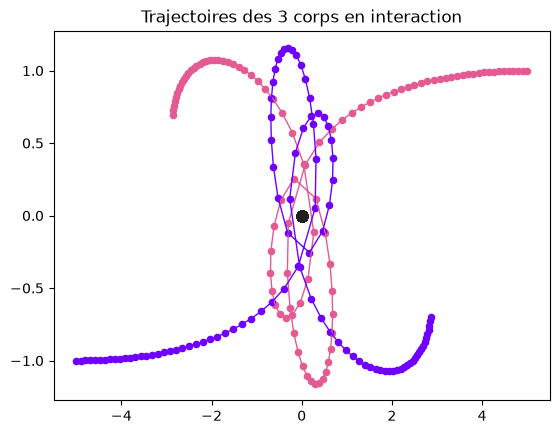

In [264]:
def draw(simulation, masses, colors=None, scale=10.):
    fig, ax = plt.subplots()
    for i in range(masses.shape[0]):
        x,y = simulation[:,:,i].T
        # On prend la transposée pour obtenir la liste des positios successives
        ax.scatter(x,y,color=colors[i],s=masses[i]*scale)
        # Pour tracer le nuage de points de la trajectoire
        # Un point est d'autant plus gros que sa masse est grande
        plt.plot(x,y,lw=1,color=colors[i])
        # (Pour tracer les lignes qui relient les points, je trouve que ça aide à comprendre la progression de la trajectoire
    plt.title("Trajectoires des 3 corps en interaction")
    plt.show()

masses, positions, speeds = init3()
colors3 = np.array([
    [32, 32, 32],
    (228, 90, 146),
    (111, 0, 255),
]) / 255
draw(simulate(masses, positions, speeds), masses,colors=colors3,scale=20.)

## Partie optionnelle (option 2 : rendu interactif)

In [265]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animation(simulation,masses,colors=None):
    fig,ax = plt.subplots()
    points = ax.scatter(simulation[0,0,:],simulation[0,1,:],c=colors3)
    # Au lieu de tracer corps par corps on trace instant par instant les 3 corps en même temps
    def update(etape):
        points.set_offsets(simulation[etape].T)
        return points
    return FuncAnimation(fig,update,frames=simulation.shape[0],interval=50)
    
anim = animation(simulate(masses, positions, speeds),masses,colors3)
plt.close()
HTML(anim.to_jshtml())